# Phase Status and Proposed Experiments

This notebook is a compact experiment brief for the current reinforcement-learning stocks phase. It captures the current status, the active model anchors, and the next experiments to run with clear success criteria.

## Current Phase

- Active phase: quantitative refinement and champion retraining
- Main focus: Binary PPO, discrete action masking, and economic realism
- Current promoted tickers: NVDA, AMD, MU
- Current risk focus: policy collapse, reward shaping leakage, and min-hold friction

## Current Status Snapshot

| Ticker | Status | Run label | Seeds | Key note |
|---|---|---|---|---|
| NVDA | Promoted | `nvda-ppo-minhold1-extended` | 3, 13, 7, 42 | Raw feature space, `min_hold_bars=1` |
| AMD | Promoted | `amd-masked-ppo-v1-low-friction` | 21 | Needs low-friction recovery path |
| MU | Promoted | `mu-masked-ppo-v1-tuned` | 3, 7, 42 | High-turnover regime, watch drift |

### Main constraints

- AMD collapsed under strict friction, so exploration needs lower reward pressure before any further promotion decision.
- NVDA remains the structural control anchor because its min-hold setting is already validated.
- MU is promoted but should be rechecked for entropy collapse and regime sensitivity.

In [ ]:
from pathlib import Path
import json

root = Path('/Users/nettenz/Projects/agentic-dev/reinforcement-learning-stocks')
project_state_path = root / 'PROJECT_STATE.md'
ensemble_config_path = root / 'staging' / 'models' / 'ensemble_config.json'

print('PROJECT_STATE exists:', project_state_path.exists())
print('ensemble_config exists:', ensemble_config_path.exists())

if project_state_path.exists():
    text = project_state_path.read_text(encoding='utf-8')
    print('PROJECT_STATE preview:')
    for line in text.splitlines()[:25]:
        print(line)

if ensemble_config_path.exists():
    config = json.loads(ensemble_config_path.read_text(encoding='utf-8'))
    print('\nActive ensemble anchors:')
    for ticker in ('nvda', 'amd', 'mu'):
        item = config.get(ticker, {})
        print(f"{ticker.upper()}: run_label={item.get('run_label')} seeds={item.get('active_seeds')} use_stationary_features={item.get('use_stationary_features', None)}")

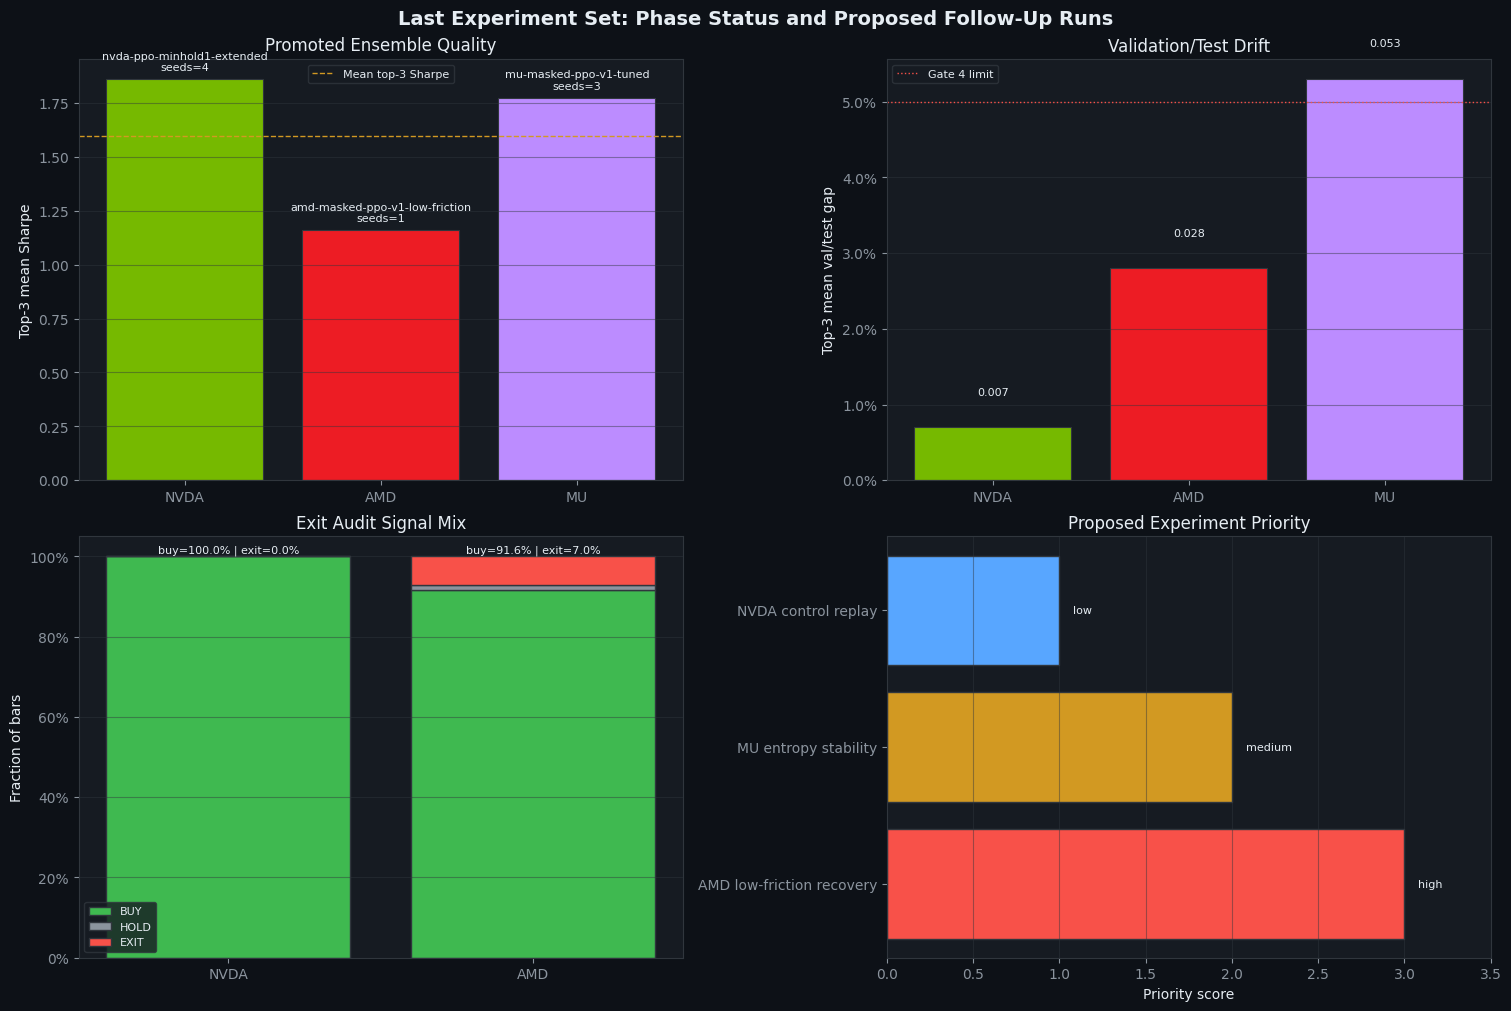

Current phase metrics:
ticker                      run_label  seeds  sharpe   gap
  NVDA     nvda-ppo-minhold1-extended      4   1.860 0.007
   AMD amd-masked-ppo-v1-low-friction      1   1.159 0.028
    MU         mu-masked-ppo-v1-tuned      3   1.773 0.053

Proposed experiments:
                     name  priority status
AMD low-friction recovery         3   high
     MU entropy stability         2 medium
      NVDA control replay         1    low


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

root = Path.cwd()
if not (root / "PROJECT_STATE.md").exists():
    root = Path("/Users/nettenz/Projects/agentic-dev/reinforcement-learning-stocks")

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#e6edf3",
    "axes.titlecolor": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "text.color": "#e6edf3",
    "grid.color": "#30363d",
    "grid.alpha": 0.45,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family": "DejaVu Sans",
    "font.size": 10,
})

NVDA_C = "#76b900"
AMD_C = "#ed1c24"
MU_C = "#bc8cff"
GREEN = "#3fb950"
RED = "#f85149"
BLUE = "#58a6ff"
AMBER = "#d29922"
MUTED = "#8b949e"

ensemble_path = root / "staging" / "models" / "ensemble_config.json"
config = json.loads(ensemble_path.read_text(encoding="utf-8"))

summary_dir = root / "data" / "audit" / "exit_signal_sweep"
summary_rows = []
for ticker in ("nvda", "amd"):
    summary_path = summary_dir / f"{ticker}_exit_audit_summary.json"
    if summary_path.exists():
        summary_rows.append(json.loads(summary_path.read_text(encoding="utf-8")))
summary_df = pd.DataFrame(summary_rows)

metrics = pd.DataFrame([
    {
        "ticker": ticker.upper(),
        "run_label": config.get(ticker, {}).get("run_label", ""),
        "seeds": len(config.get(ticker, {}).get("active_seeds", [])),
        "sharpe": config.get(ticker, {}).get("top_3_mean_sharpe", np.nan),
        "gap": config.get(ticker, {}).get("top_3_mean_val_test_gap", np.nan),
    }
    for ticker in ("nvda", "amd", "mu")
])

proposed = pd.DataFrame([
    {"name": "AMD low-friction recovery", "priority": 3, "status": "high"},
    {"name": "MU entropy stability", "priority": 2, "status": "medium"},
    {"name": "NVDA control replay", "priority": 1, "status": "low"},
])

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
fig.suptitle("Last Experiment Set: Phase Status and Proposed Follow-Up Runs", fontsize=14, fontweight="bold")

# Panel 1: Sharpe summary
ax = axes[0, 0]
colors = [NVDA_C, AMD_C, MU_C]
ax.bar(metrics["ticker"], metrics["sharpe"], color=colors, edgecolor="#30363d", linewidth=0.8)
ax.axhline(metrics["sharpe"].mean(), color=AMBER, linestyle="--", linewidth=1.0, label="Mean top-3 Sharpe")
ax.set_title("Promoted Ensemble Quality")
ax.set_ylabel("Top-3 mean Sharpe")
ax.grid(True, axis="y")
for i, row in metrics.iterrows():
    ax.text(i, row["sharpe"] + 0.03, f"{row['run_label']}\nseeds={row['seeds']}", ha="center", va="bottom", fontsize=8)
ax.legend(fontsize=8)

# Panel 2: Val/test gap summary
ax = axes[0, 1]
ax.bar(metrics["ticker"], metrics["gap"], color=colors, edgecolor="#30363d", linewidth=0.8)
ax.axhline(0.05, color=RED, linestyle=":", linewidth=1.0, label="Gate 4 limit")
ax.set_title("Validation/Test Drift")
ax.set_ylabel("Top-3 mean val/test gap")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
ax.grid(True, axis="y")
for i, row in metrics.iterrows():
    ax.text(i, row["gap"] + 0.004, f"{row['gap']:.3f}", ha="center", va="bottom", fontsize=8)
ax.legend(fontsize=8)

# Panel 3: Exit signal composition
ax = axes[1, 0]
if not summary_df.empty:
    x = np.arange(len(summary_df))
    buy = summary_df["buy_rate_pct"].astype(float).values / 100.0
    hold = summary_df["hold_rate_pct"].astype(float).values / 100.0
    exit_rate = summary_df["exit_signal_rate_pct"].astype(float).values / 100.0
    ax.bar(x, buy, label="BUY", color=GREEN, edgecolor="#30363d")
    ax.bar(x, hold, bottom=buy, label="HOLD", color=MUTED, edgecolor="#30363d")
    ax.bar(x, exit_rate, bottom=buy + hold, label="EXIT", color=RED, edgecolor="#30363d")
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["ticker"].tolist())
    ax.set_ylim(0, 1.05)
    ax.set_title("Exit Audit Signal Mix")
    ax.set_ylabel("Fraction of bars")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.grid(True, axis="y")
    ax.legend(fontsize=8)
    for xi, row in enumerate(summary_df.itertuples(index=False)):
        ax.text(xi, 1.01, f"buy={row.buy_rate_pct:.1f}% | exit={row.exit_signal_rate_pct:.1f}%", ha="center", fontsize=8)
else:
    ax.text(0.5, 0.5, "No exit audit summaries found", ha="center", va="center", color=MUTED, transform=ax.transAxes)
    ax.set_axis_off()

# Panel 4: Proposed experiments priority
ax = axes[1, 1]
priority_colors = [RED, AMBER, BLUE]
ax.barh(proposed["name"], proposed["priority"], color=priority_colors, edgecolor="#30363d")
ax.set_title("Proposed Experiment Priority")
ax.set_xlabel("Priority score")
ax.set_xlim(0, 3.5)
ax.grid(True, axis="x")
for y, row in enumerate(proposed.itertuples(index=False)):
    ax.text(row.priority + 0.08, y, row.status, va="center", fontsize=8, color="#e6edf3")

fig.savefig(root / "data" / "audit" / "phase_status_experiment_summary.png", dpi=180, bbox_inches="tight")
plt.show()

print("Current phase metrics:")
print(metrics.to_string(index=False))
print("\nProposed experiments:")
print(proposed.to_string(index=False))


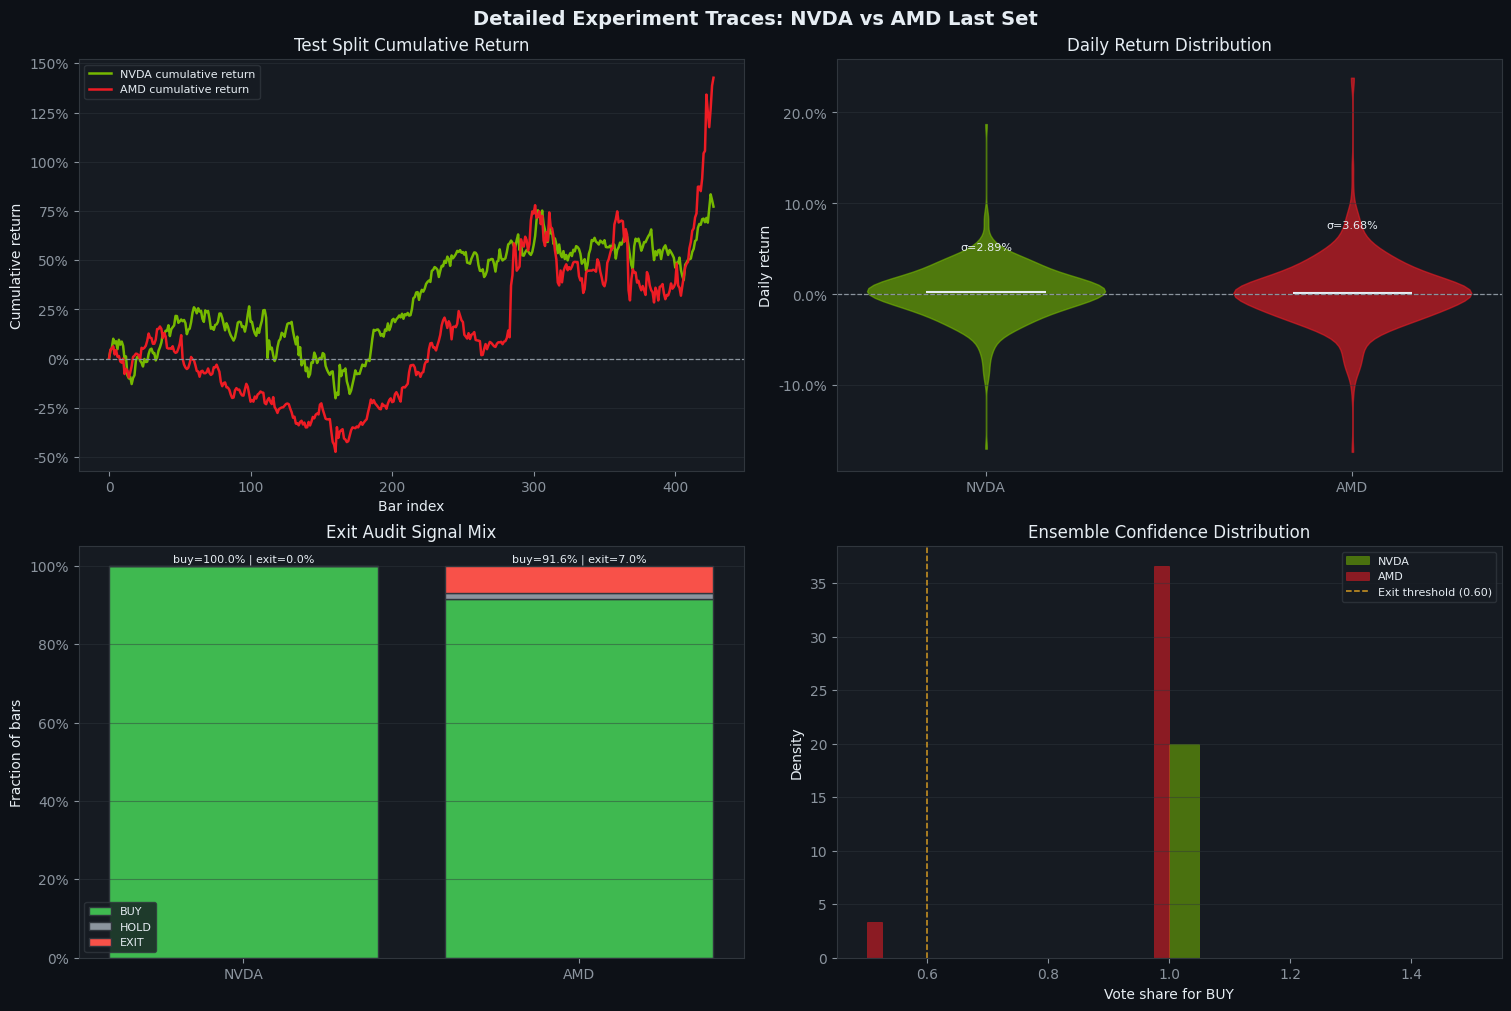

Saved detailed trace figure to data/audit/phase_status_experiment_trace.png
NVDA: buy=100.0%, hold=0.0%, exit=0.0%, avg_buy_vote_share=1.0
AMD: buy=91.57%, hold=1.41%, exit=7.03%, avg_buy_vote_share=0.9578


In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

root = Path.cwd()
if not (root / "PROJECT_STATE.md").exists():
    root = Path("/Users/nettenz/Projects/agentic-dev/reinforcement-learning-stocks")

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#e6edf3",
    "axes.titlecolor": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "text.color": "#e6edf3",
    "grid.color": "#30363d",
    "grid.alpha": 0.45,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family": "DejaVu Sans",
    "font.size": 10,
})

NVDA_C = "#76b900"
AMD_C = "#ed1c24"
MU_C = "#bc8cff"
GREEN = "#3fb950"
RED = "#f85149"
BLUE = "#58a6ff"
AMBER = "#d29922"
MUTED = "#8b949e"

summary_dir = root / "data" / "audit" / "exit_signal_sweep"


def load_parquet(ticker: str):
    candidates = [
        root / "data" / f"tech_training_data_{ticker}.parquet",
        root / "data" / f"tech_training_data_{ticker}_stationary.parquet",
    ]
    for path in candidates:
        if path.exists():
            return pd.read_parquet(path), path
    return None, None


def test_split(df: pd.DataFrame) -> pd.DataFrame:
    split_idx = int(len(df) * 0.85)
    return df.iloc[split_idx:].copy().reset_index(drop=True)


def price_series(df: pd.DataFrame):
    for column in ("RawClose", "Close", "close"):
        if column in df.columns:
            return df[column].astype(float).values, column
    return None, None


price_data = {}
for ticker in ("nvda", "amd"):
    df, source_path = load_parquet(ticker)
    if df is None:
        continue
    test_df = test_split(df)
    px, price_col = price_series(test_df)
    if px is None or len(px) < 2:
        continue
    rets = np.diff(px) / px[:-1]
    price_data[ticker.upper()] = {
        "source": source_path.name,
        "price_col": price_col,
        "prices": px,
        "cum": px / px[0] - 1.0,
        "rets": rets,
    }

summary_data = {}
for ticker in ("nvda", "amd"):
    summary_path = summary_dir / f"{ticker}_exit_audit_summary.json"
    csv_path = summary_dir / f"{ticker}_exit_audit.csv"
    if summary_path.exists():
        summary_data[ticker.upper()] = json.loads(summary_path.read_text(encoding="utf-8"))
    if csv_path.exists():
        summary_data.setdefault(ticker.upper(), {})["csv"] = pd.read_csv(csv_path)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
fig.suptitle("Detailed Experiment Traces: NVDA vs AMD Last Set", fontsize=14, fontweight="bold")

# Panel 1: cumulative return traces
ax = axes[0, 0]
for ticker, color in (("NVDA", NVDA_C), ("AMD", AMD_C)):
    if ticker not in price_data:
        continue
    cum = price_data[ticker]["cum"]
    ax.plot(cum, linewidth=1.8, color=color, label=f"{ticker} cumulative return")
ax.axhline(0, color=MUTED, linestyle="--", linewidth=0.9)
ax.set_title("Test Split Cumulative Return")
ax.set_xlabel("Bar index")
ax.set_ylabel("Cumulative return")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(True, axis="y")
ax.legend(fontsize=8)

# Panel 2: daily return distribution
ax = axes[0, 1]
ret_labels = []
ret_series = []
ret_colors = []
for ticker, color in (("NVDA", NVDA_C), ("AMD", AMD_C)):
    if ticker in price_data:
        ret_labels.append(ticker)
        ret_series.append(price_data[ticker]["rets"])
        ret_colors.append(color)
if ret_series:
    parts = ax.violinplot(ret_series, positions=np.arange(len(ret_series)), showmedians=True, showextrema=False, widths=0.65)
    for body, color in zip(parts["bodies"], ret_colors):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.6)
    parts["cmedians"].set_color("#e6edf3")
    parts["cmedians"].set_linewidth(1.5)
    ax.set_xticks(np.arange(len(ret_labels)))
    ax.set_xticklabels(ret_labels)
    ax.axhline(0, color=MUTED, linestyle="--", linewidth=0.9)
    ax.set_title("Daily Return Distribution")
    ax.set_ylabel("Daily return")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.grid(True, axis="y")
    for idx, series in enumerate(ret_series):
        ax.text(idx, np.percentile(series, 97), f"σ={np.std(series):.2%}", ha="center", va="bottom", fontsize=8)
else:
    ax.text(0.5, 0.5, "No return data found", ha="center", va="center", color=MUTED, transform=ax.transAxes)
    ax.set_axis_off()

# Panel 3: exit/hold/buy composition and confidence
ax = axes[1, 0]
if "NVDA" in summary_data and "AMD" in summary_data:
    rows = [summary_data["NVDA"], summary_data["AMD"]]
    x = np.arange(len(rows))
    buy = np.array([row["buy_rate_pct"] for row in rows]) / 100.0
    hold = np.array([row["hold_rate_pct"] for row in rows]) / 100.0
    exit_rate = np.array([row["exit_signal_rate_pct"] for row in rows]) / 100.0
    ax.bar(x, buy, label="BUY", color=GREEN, edgecolor="#30363d")
    ax.bar(x, hold, bottom=buy, label="HOLD", color=MUTED, edgecolor="#30363d")
    ax.bar(x, exit_rate, bottom=buy + hold, label="EXIT", color=RED, edgecolor="#30363d")
    ax.set_xticks(x)
    ax.set_xticklabels(["NVDA", "AMD"])
    ax.set_ylim(0, 1.05)
    ax.set_title("Exit Audit Signal Mix")
    ax.set_ylabel("Fraction of bars")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.grid(True, axis="y")
    ax.legend(fontsize=8)
    for idx, row in enumerate(rows):
        ax.text(idx, 1.01, f"buy={row['buy_rate_pct']:.1f}% | exit={row['exit_signal_rate_pct']:.1f}%", ha="center", fontsize=8)
else:
    ax.text(0.5, 0.5, "No audit summary data found", ha="center", va="center", color=MUTED, transform=ax.transAxes)
    ax.set_axis_off()

# Panel 4: confidence histogram from actual vote share
ax = axes[1, 1]
conf_found = False
for ticker, color in (("NVDA", NVDA_C), ("AMD", AMD_C)):
    csv_df = summary_data.get(ticker, {}).get("csv")
    if csv_df is None or "vote_share_buy" not in csv_df.columns:
        continue
    vals = csv_df["vote_share_buy"].astype(float).values
    ax.hist(vals, bins=20, alpha=0.55, color=color, label=ticker, edgecolor=color, linewidth=0.5, density=True)
    conf_found = True
if conf_found:
    ax.axvline(0.60, color=AMBER, linestyle="--", linewidth=1.1, label="Exit threshold (0.60)")
    ax.set_title("Ensemble Confidence Distribution")
    ax.set_xlabel("Vote share for BUY")
    ax.set_ylabel("Density")
    ax.grid(True, axis="y")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No confidence data found", ha="center", va="center", color=MUTED, transform=ax.transAxes)
    ax.set_axis_off()

fig.savefig(root / "data" / "audit" / "phase_status_experiment_trace.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved detailed trace figure to data/audit/phase_status_experiment_trace.png")
for ticker in ("NVDA", "AMD"):
    if ticker in summary_data:
        row = summary_data[ticker]
        print(f"{ticker}: buy={row.get('buy_rate_pct')}%, hold={row.get('hold_rate_pct')}%, exit={row.get('exit_signal_rate_pct')}%, avg_buy_vote_share={row.get('avg_buy_vote_share')}")


## Proposed Experiments

### 1. AMD low-friction recovery

Goal: restore meaningful trade activity without reintroducing the reward-insulation path that can hide friction problems.

Suggested configuration:

- `ticker=amd`
- `binary_actions=True`
- `use_action_masking=True`
- `use_cooldown_obs=True`
- `min_hold_bars=3`
- `reward_ignore_transaction_cost=False`
- `reward_action_bonus_scale=0.0`
- `reward_turnover_penalty_scale=0.00`
- `reward_hold_penalty_scale=0.01`

Success criteria:

- `test_trade_rate` returns into the valid band
- `test_actionable_accuracy` stays at or above gate threshold
- `test_return_cv_by_config < 0.50`
- no cash-collapse behavior

### 2. MU entropy stability check

Goal: verify that the promoted MU policy remains high-signal rather than overconfident or over-traded.

Suggested configuration:

- `ticker=mu`
- `binary_actions=True`
- `use_action_masking=True`
- `use_cooldown_obs=True`
- `reward_ignore_transaction_cost=False`
- `reward_action_bonus_scale=0.0`

Success criteria:

- entropy does not collapse toward zero
- trade rate remains explainable under the sector regime
- validation-to-test drift stays within gate tolerance unless a waiver is documented

### 3. NVDA control replay

Goal: confirm that the `min_hold_bars=1` structural fix still dominates after the latest environment changes.

Suggested configuration:

- `ticker=nvda`
- `binary_actions=True`
- `min_hold_bars=1`
- `use_action_masking=True`
- `reward_ignore_transaction_cost=False`

Success criteria:

- alpha remains positive
- trade rate remains in the healthy operating band
- no regression in actionable accuracy or win rate

## Execution Notes

- Use the current virtual environment for all runs.
- Keep `sb3-contrib` installed when masking is enabled.
- Re-evaluate each run through the standard gate flow before any promotion update.
- If the dashboard needs to consume the results, keep the experiment labels stable so the leaderboard and signal tooling stay aligned.